In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import pickle

In [2]:
df=pd.read_csv("laptop_data.csv")

In [3]:

df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [4]:
df.shape

(1303, 12)

In [5]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [6]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

In [7]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.describe()

,Inches,Price
count,1274.000000,1274.000000
mean,15.022449,60503.185074
std,1.429940,37333.222977
min,10.100000,9270.720000
25%,14.000000,32495.605200
50%,15.600000,52693.920000
75%,15.600000,79773.480000
max,18.400000,324954.720000


In [10]:
df.select_dtypes(include="object").columns

Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')

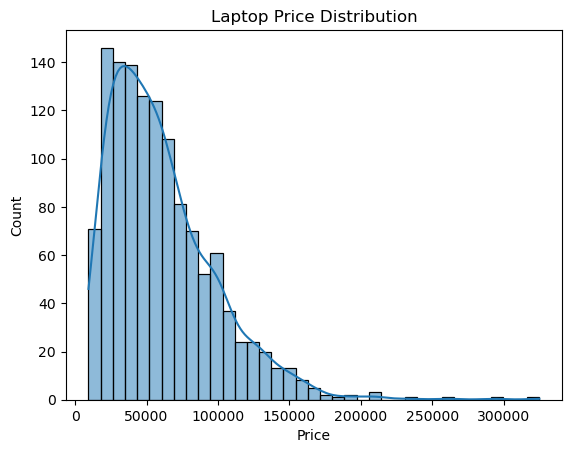

In [11]:
sns.histplot(df["Price"], kde=True)

plt.title("Laptop Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

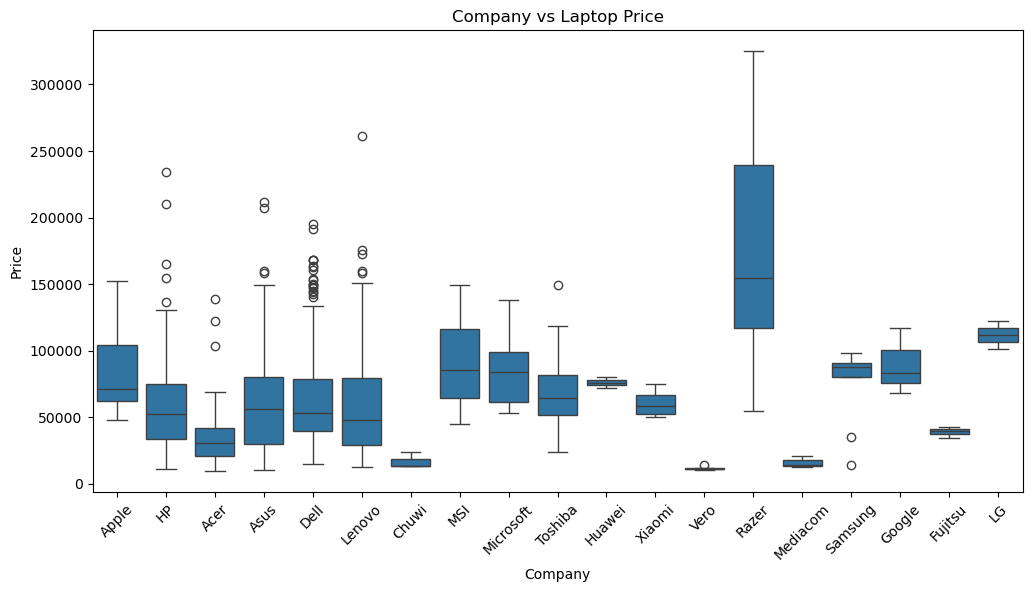

In [12]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x="Company",
    y="Price",
    data=df
)

plt.xticks(rotation=45)

plt.title("Company vs Laptop Price")

plt.show()

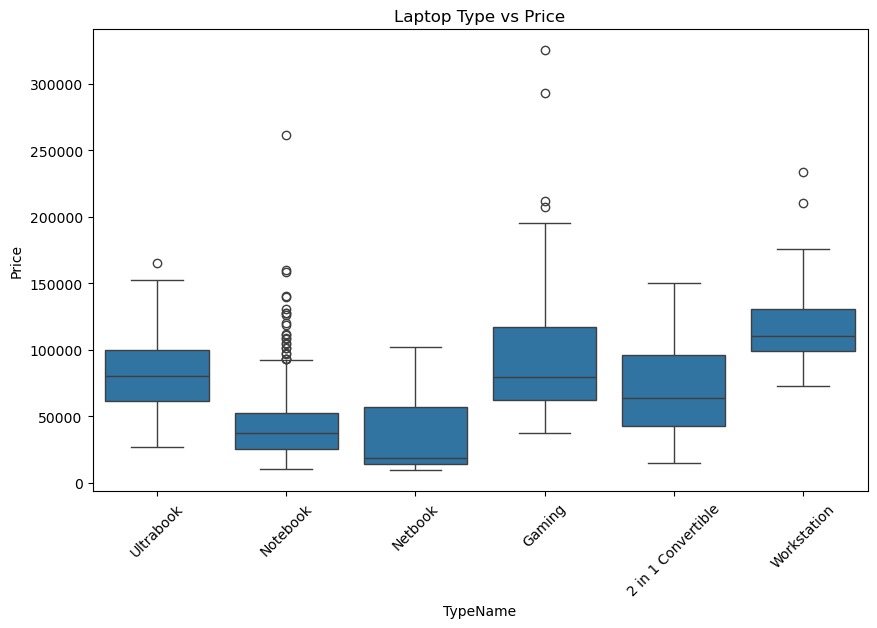

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="TypeName",
    y="Price",
    data=df
)

plt.xticks(rotation=45)

plt.title("Laptop Type vs Price")

plt.show()

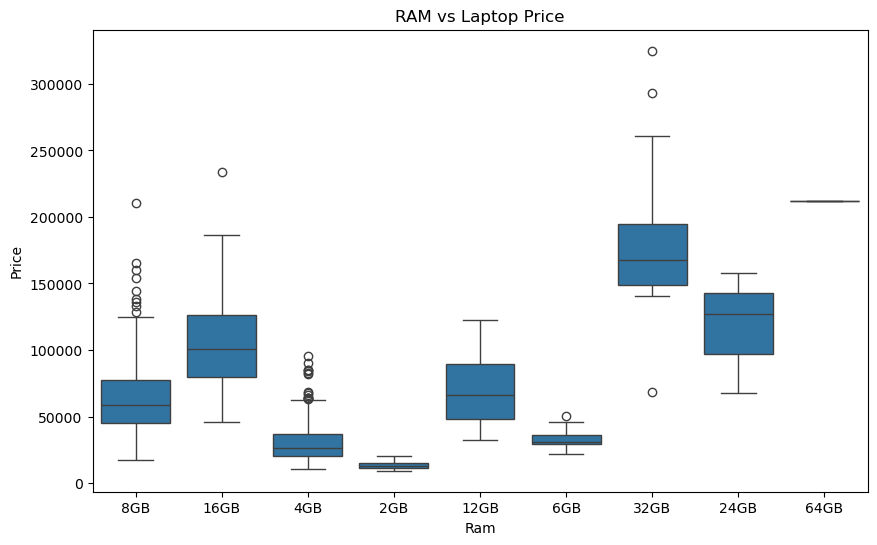

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Ram",
    y="Price",
    data=df
)

plt.title("RAM vs Laptop Price")

plt.show()

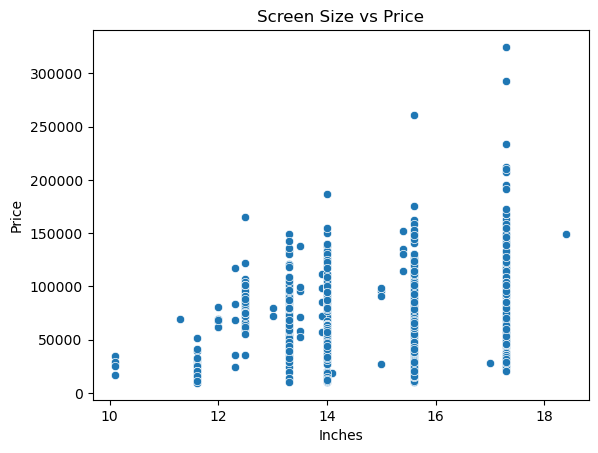

In [15]:
sns.scatterplot(
    x="Inches",
    y="Price",
    data=df
)

plt.title("Screen Size vs Price")

plt.show()

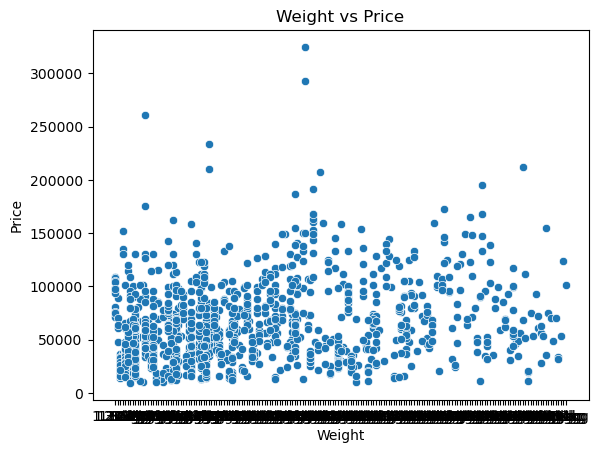

In [16]:
sns.scatterplot(
    x="Weight",
    y="Price",
    data=df
)

plt.title("Weight vs Price")

plt.show()

In [17]:
df["Ram"] = df["Ram"].str.replace("GB", "").astype(int)

In [18]:
df["Weight"] = df["Weight"].str.replace("kg", "").astype(float)

In [19]:
def get_cpu_brand(cpu):
    
    if "Intel" in cpu:
        return "Intel"
    
    elif "AMD" in cpu:
        return "AMD"
    
    elif "Samsung" in cpu:
        return "Samsung"
    
    else:
        return "Other"

In [20]:
df["Cpu_Brand"] = df["Cpu"].apply(get_cpu_brand)

In [21]:
df["Cpu_Brand"].value_counts()

Cpu_Brand
Intel      1213
AMD          60
Samsung       1
Name: count, dtype: int64

In [22]:
def get_gpu_brand(gpu):
    
    if "Intel" in gpu:
        return "Intel"
    
    elif "Nvidia" in gpu:
        return "Nvidia"
    
    elif "AMD" in gpu:
        return "AMD"
    
    elif "ARM" in gpu:
        return "ARM"
    
    else:
        return "Other"

In [23]:
df["Gpu_Brand"] = df["Gpu"].apply(get_gpu_brand)

In [24]:
df["Gpu_Brand"].value_counts()

Gpu_Brand
Intel     703
Nvidia    396
AMD       174
ARM         1
Name: count, dtype: int64

In [25]:
df["Touchscreen"] = df["ScreenResolution"].apply(
    lambda x: 1 if "Touchscreen" in x else 0
)

In [26]:
df["Touchscreen"].value_counts()

Touchscreen
0    1086
1     188
Name: count, dtype: int64

In [27]:
df["Resolution"] = df["ScreenResolution"].str.extract(
    r"(\d+x\d+)"
)

In [28]:
df[["ScreenResolution", "Resolution"]].head()

,ScreenResolution,Resolution
0,IPS Panel Retina Display 2560x1600,2560x1600
1,1440x900,1440x900
2,Full HD 1920x1080,1920x1080
3,IPS Panel Retina Display 2880x1800,2880x1800
4,IPS Panel Retina Display 2560x1600,2560x1600


In [29]:
df["X_res"] = df["Resolution"].str.split("x").str[0].astype(int)

In [30]:
df["Y_res"] = df["Resolution"].str.split("x").str[1].astype(int)

In [31]:
df["Ppi"] = (
    np.sqrt(
        df["X_res"] ** 2 +
        df["Y_res"] ** 2
    )
    / df["Inches"]
)

In [32]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu_Brand,Gpu_Brand,Touchscreen,Resolution,X_res,Y_res,Ppi
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel,0,2560x1600,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel,0,1440x900,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel,0,1920x1080,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,AMD,0,2880x1800,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel,0,2560x1600,2560,1600,226.983005


In [33]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
cat_features = [
    "Company",
    "TypeName",
    "ScreenResolution",
    "Cpu",
    "Memory",
    "Gpu",
    "OpSys",
    "Cpu_Brand",
    "Gpu_Brand",
    "Resolution"
]

In [36]:
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [37]:
model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.2,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [38]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 32489.3095135	total: 261ms	remaining: 6m 31s
100:	learn: 6699.7120653	total: 7.74s	remaining: 1m 47s
200:	learn: 3969.2898106	total: 15.2s	remaining: 1m 38s
300:	learn: 2465.5564276	total: 22.4s	remaining: 1m 29s
400:	learn: 1699.2322334	total: 29.3s	remaining: 1m 20s
500:	learn: 1192.7263686	total: 36.3s	remaining: 1m 12s
600:	learn: 855.0424005	total: 43.4s	remaining: 1m 4s
700:	learn: 588.7345253	total: 50.5s	remaining: 57.6s
800:	learn: 447.5305903	total: 57.7s	remaining: 50.4s
900:	learn: 348.8960862	total: 1m 4s	remaining: 43.1s
1000:	learn: 264.2604598	total: 1m 11s	remaining: 35.9s
1100:	learn: 200.7451284	total: 1m 18s	remaining: 28.6s
1200:	learn: 159.9510040	total: 1m 25s	remaining: 21.4s
1300:	learn: 127.5322361	total: 1m 32s	remaining: 14.2s
1400:	learn: 100.6860012	total: 1m 39s	remaining: 7.06s
1499:	learn: 81.9727051	total: 1m 46s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1500, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=100)

In [39]:
y_pred = model.predict(X_test)

In [40]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8002839366491739


In [41]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 10494.233972491695


In [42]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 18499.9459870099


depths = [4, 5, 6, 7, 8, 9, 10]

for depth in depths:

    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.05,
        depth=depth,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    print(
        "Depth:",
        depth,
        "R²:",
        score
    )

In [43]:
print("R² Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

R² Score : 0.8002839366491739
MAE      : 10494.233972491695
RMSE     : 18499.9459870099


In [44]:
iterations_list = [500, 1000, 1500, 2000]

for iterations in iterations_list:

    model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=0.055,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    print(
        "Iterations:",
        iterations,
        "R²:",
        score
    )

Iterations: 500 R²: 0.8127172232920447
Iterations: 1000 R²: 0.8121347532756282
Iterations: 1500 R²: 0.8112779808152544
Iterations: 2000 R²: 0.8109615882256983


In [45]:
learning_rates = [0.03,0.035,0.04,0.045,0.05,0.06,0.07 ,0.1, 0.15, 0.2, 0.3]

for lr in learning_rates:

    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=lr,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    print(
        "Learning Rate:",
        lr,
        "R²:",
        score
    )

Learning Rate: 0.03 R²: 0.812820429050868
Learning Rate: 0.035 R²: 0.8032471567405958
Learning Rate: 0.04 R²: 0.8111063369822822
Learning Rate: 0.045 R²: 0.8153174360564277
Learning Rate: 0.05 R²: 0.8118310051860391
Learning Rate: 0.06 R²: 0.8073966158547982
Learning Rate: 0.07 R²: 0.8031718952254744
Learning Rate: 0.1 R²: 0.7964021516211265
Learning Rate: 0.15 R²: 0.7964226855661168
Learning Rate: 0.2 R²: 0.8002839366491739
Learning Rate: 0.3 R²: 0.7926174485442304


In [46]:
final_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.045,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [ ]:
final_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 35329.5086284	total: 45.3ms	remaining: 1m 7s
100:	learn: 13959.7992526	total: 7.96s	remaining: 1m 50s
200:	learn: 10324.1772824	total: 15.8s	remaining: 1m 42s
300:	learn: 8419.7349591	total: 23.6s	remaining: 1m 34s
400:	learn: 7111.7952937	total: 31.3s	remaining: 1m 25s
500:	learn: 6229.1666231	total: 39.1s	remaining: 1m 17s
600:	learn: 5392.2776166	total: 46.8s	remaining: 1m 9s
700:	learn: 4736.5875883	total: 54.3s	remaining: 1m 1s
800:	learn: 4207.3214631	total: 1m 2s	remaining: 54.3s
900:	learn: 3776.4818805	total: 1m 11s	remaining: 47.3s
1000:	learn: 3407.7668426	total: 1m 20s	remaining: 40.1s
1100:	learn: 3090.6381079	total: 1m 29s	remaining: 32.4s
1200:	learn: 2804.3678779	total: 1m 38s	remaining: 24.5s
1300:	learn: 2557.4574582	total: 1m 47s	remaining: 16.5s


In [ ]:
y_pred = final_model.predict(X_test)

In [ ]:
print("R² Score :", r2_score(y_test, y_pred))

print(
    "MAE :",
    mean_absolute_error(y_test, y_pred)
)

print(
    "RMSE :",
    np.sqrt(mean_squared_error(y_test, y_pred))
)

In [ ]:
importance = final_model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance